# Flights Data Exploration Challenge

In this challenge, you'll explore a real-world dataset containing flights data from the US Department of Transportation.

Let's start by loading and viewing the data.

In [32]:
import pandas as pd

df_flights = pd.read_csv('data/flights.csv')
df_flights.head()

,Year,Month,DayofMonth,DayOfWeek,Carrier,OriginAirportID,OriginAirportName,OriginCity,OriginState,DestAirportID,DestAirportName,DestCity,DestState,CRSDepTime,DepDelay,DepDel15,CRSArrTime,ArrDelay,ArrDel15,Cancelled
0,2013,9,16,1,DL,15304,Tampa International,Tampa,FL,12478,John F. Kennedy International,New York,NY,1539,4,0.0,1824,13,0,0
1,2013,9,23,1,WN,14122,Pittsburgh International,Pittsburgh,PA,13232,Chicago Midway International,Chicago,IL,710,3,0.0,740,22,1,0
2,2013,9,7,6,AS,14747,Seattle/Tacoma International,Seattle,WA,11278,Ronald Reagan Washington National,Washington,DC,810,-3,0.0,1614,-7,0,0
3,2013,7,22,1,OO,13930,Chicago O'Hare International,Chicago,IL,11042,Cleveland-Hopkins International,Cleveland,OH,804,35,1.0,1027,33,1,0
4,2013,5,16,4,DL,13931,Norfolk International,Norfolk,VA,10397,Hartsfield-Jackson Atlanta International,Atlanta,GA,545,-1,0.0,728,-9,0,0


The dataset contains observations of US domestic flights in 2013, and consists of the following fields:

- **Year**: The year of the flight (all records are from 2013)
- **Month**: The month of the flight
- **DayofMonth**: The day of the month on which the flight departed
- **DayOfWeek**: The day of the week on which the flight departed - from 1 (Monday) to 7 (Sunday)
- **Carrier**: The two-letter abbreviation for the airline.
- **OriginAirportID**: A unique numeric identifier for the departure aiport
- **OriginAirportName**: The full name of the departure airport
- **OriginCity**: The departure airport city
- **OriginState**: The departure airport state
- **DestAirportID**: A unique numeric identifier for the destination aiport
- **DestAirportName**: The full name of the destination airport
- **DestCity**: The destination airport city
- **DestState**: The destination airport state
- **CRSDepTime**: The scheduled departure time
- **DepDelay**: The number of minutes departure was delayed (flight that left ahead of schedule have a negative value)
- **DelDelay15**: A binary indicator that departure was delayed by more than 15 minutes (and therefore considered "late")
- **CRSArrTime**: The scheduled arrival time
- **ArrDelay**: The number of minutes arrival was delayed (flight that arrived ahead of schedule have a negative value)
- **ArrDelay15**: A binary indicator that arrival was delayed by more than 15 minutes (and therefore considered "late")
- **Cancelled**: A binary indicator that the flight was cancelled

Your challenge is to explore the flight data to analyze possible factors that affect delays in departure or arrival of a flight.

1. Start by cleaning the data.
    - Identify any null or missing data, and impute appropriate replacement values.
    - Identify and eliminate any outliers in the **DepDelay** and **ArrDelay** columns.
2. Explore the cleaned data.
    - View summary statistics for the numeric fields in the dataset.
    - Determine the distribution of the **DepDelay** and **ArrDelay** columns.
    - Use statistics, aggregate functions, and visualizations to answer the following questions:
        - *What are the average (mean) departure and arrival delays?*
        - *How do the carriers compare in terms of arrival delay performance?*
        - *Is there a noticable difference in arrival delays for different days of the week?*
        - *Which departure airport has the highest average departure delay?*
        - *Do **late** departures tend to result in longer arrival delays than on-time departures?*
        - *Which route (from origin airport to destination airport) has the most **late** arrivals?*
        - *Which route has the highest average arrival delay?*
        
Add markdown and code cells as required to create your solution.

> **Note**: There is no single "correct" solution. A sample solution is provided in [01 - Flights Challenge.ipynb](01%20-%20Flights%20Solution.ipynb).

In [33]:
# Identify all columns with null values
df_flights.isnull().sum()

Year                    0
Month                   0
DayofMonth              0
DayOfWeek               0
Carrier                 0
OriginAirportID         0
OriginAirportName       0
OriginCity              0
OriginState             0
DestAirportID           0
DestAirportName         0
DestCity                0
DestState               0
CRSDepTime              0
DepDelay                0
DepDel15             2761
CRSArrTime              0
ArrDelay                0
ArrDel15                0
Cancelled               0
dtype: int64

In [34]:
# Show DepDelay where DepDel15 is null
df_flights[df_flights['DepDel15'].isnull()]['DepDelay']

171       0
359       0
429       0
545       0
554       0
         ..
271410    0
271607    0
271634    0
271671    0
271885    0
Name: DepDelay, Length: 2761, dtype: int64

In [35]:
# Inplace update depdel15 to 0 when null
df_flights['DepDel15'].fillna(0, inplace=True)

/var/folders/7j/x5nq3k155078tmbmpnmrk81h0000gp/T/ipykernel_36850/1720105861.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_flights['DepDel15'].fillna(0, inplace=True)


In [36]:
# Remove columns where DepDelay is higher than 90th percentile
df_flights = df_flights[df_flights['ArrDelay'] <= df_flights['ArrDelay'].quantile(.90)]

In [37]:
# Display 100 rows
df_flights.head(100)

,Year,Month,DayofMonth,DayOfWeek,Carrier,OriginAirportID,OriginAirportName,OriginCity,OriginState,DestAirportID,DestAirportName,DestCity,DestState,CRSDepTime,DepDelay,DepDel15,CRSArrTime,ArrDelay,ArrDel15,Cancelled
0,2013,9,16,1,DL,15304,Tampa International,Tampa,FL,12478,John F. Kennedy International,New York,NY,1539,4,0.0,1824,13,0,0
1,2013,9,23,1,WN,14122,Pittsburgh International,Pittsburgh,PA,13232,Chicago Midway International,Chicago,IL,710,3,0.0,740,22,1,0
2,2013,9,7,6,AS,14747,Seattle/Tacoma International,Seattle,WA,11278,Ronald Reagan Washington National,Washington,DC,810,-3,0.0,1614,-7,0,0
3,2013,7,22,1,OO,13930,Chicago O'Hare International,Chicago,IL,11042,Cleveland-Hopkins International,Cleveland,OH,804,35,1.0,1027,33,1,0
4,2013,5,16,4,DL,13931,Norfolk International,Norfolk,VA,10397,Hartsfield-Jackson Atlanta International,Atlanta,GA,545,-1,0.0,728,-9,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,2013,5,6,1,WN,14893,Sacramento International,Sacramento,CA,14107,Phoenix Sky Harbor International,Phoenix,AZ,600,0,0.0,750,-10,0,0
105,2013,10,30,3,WN,14057,Portland International,Portland,OR,14831,Norman Y. Mineta San Jose International,San Jose,CA,1310,2,0.0,1450,-8,0,0
106,2013,4,18,4,US,14100,Philadelphia International,Philadelphia,PA,11292,Denver International,Denver,CO,745,-5,0.0,959,26,1,0
107,2013,10,29,2,VX,12892,Los Angeles International,Los Angeles,CA,14747,Seattle/Tacoma International,Seattle,WA,1715,13,0.0,1950,16,1,0


<Axes: xlabel='DestAirportName'>

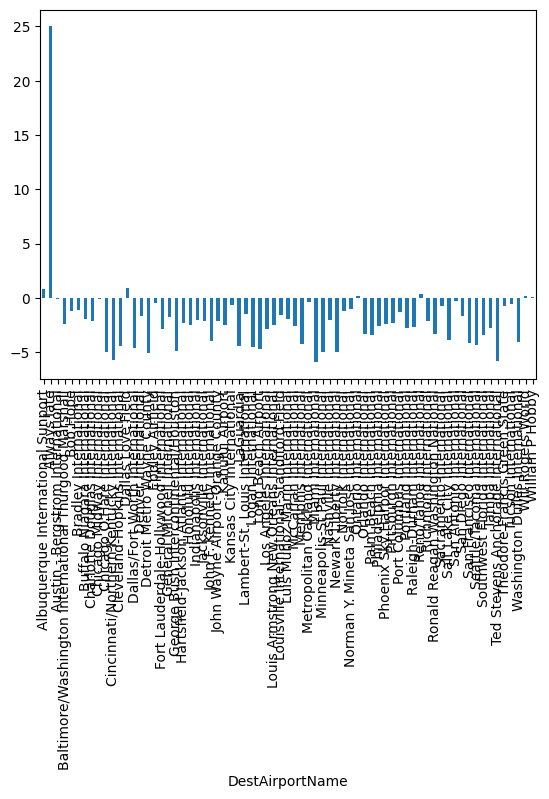

In [38]:
# Display bar chart showing average ArrDelay by DestAirportName
df_flights.groupby('DestAirportName')['ArrDelay'].mean().plot.bar()

In [39]:
# Column names in the dataset:
# ['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'Carrier',
#       'OriginAirportID', 'OriginAirportName', 'OriginCity', 'OriginState',
#       'DestAirportID', 'DestAirportName', 'DestCity', 'DestState',
#       'CRSDepTime', 'DepDelay', 'DepDel15', 'CRSArrTime', 'ArrDelay',
#       'ArrDel15', 'Cancelled'],

In [40]:
# Create a model to predict how likely a flight is to be delayed based on the day of the week and arrival airport
# Use a logistic regression model
# Split the data into training and test sets
# Train the model
# Calculate the accuracy of the model

# Create the logistic regression model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Create a dataframe with the features and target with good feature names
X = df_flights[['DayOfWeek', 'DestAirportID']]
y = df_flights['ArrDel15']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y)

# Create the model with increased max_iter for better convergence
model = LogisticRegression(solver='lbfgs', max_iter=1000)

# Train the model with feature names
model.fit(X_train, y_train)

# Calculate the accuracy of the model
model.score(X_test, y_test)


0.8683717215185747

## Comparing Multiple Classification Models

Let's train and compare Logistic Regression, Random Forest, and Gradient Boosting classifiers to see which performs best at predicting flight delays.

In [41]:
# Import additional classifiers
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

# Prepare features and target (already done above)
# X = df_flights[['DayOfWeek', 'DestAirportID']]
# y = df_flights['ArrDel15']
# X_train, X_test, y_train, y_test = train_test_split(X, y)

# Logistic Regression
logreg = LogisticRegression(solver='lbfgs', max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)
acc_logreg = accuracy_score(y_test, y_pred_logreg)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
acc_gb = accuracy_score(y_test, y_pred_gb)

# Compare results
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [acc_logreg, acc_rf, acc_gb]
})
results

,Model,Accuracy
0,Logistic Regression,0.868372
1,Random Forest,0.868404
2,Gradient Boosting,0.868404


In [42]:
# Show the confusion matrix
from sklearn.metrics import confusion_matrix
y_pred = model.predict(X_test)
confusion_matrix(y_test, y_pred)


array([[53272,     0],
       [ 8075,     0]])

In [43]:
# Show odds flight will be delayed to Las Vegas on a Monday
model.predict_proba([[1, 12892]])

/Users/parlinluhila/git/flight-delay-app/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[0.8657965, 0.1342035]])

In [44]:
# Get unique column values for origin airport and id and export to CSV
df_flights[['OriginAirportID', 'OriginAirportName']].drop_duplicates().to_csv('data/airports.csv', index=False)

In [45]:
# Save the model to a file to import later into flask
import pickle
pickle.dump(model, open('data/model.pkl', 'wb'))


In [46]:
# Find the destination airport with the most delayed arrivals
most_delayed_airport = df_flights.groupby('DestAirportName')['ArrDel15'].sum().idxmax()
most_delays = df_flights.groupby('DestAirportName')['ArrDel15'].sum().max()
print(f"Airport with most delayed arrivals: {most_delayed_airport} ({most_delays} delays)")

Airport with most delayed arrivals: Chicago O'Hare International (1619 delays)


In [47]:
# Filter for Mondays (DayOfWeek == 1) and sum delayed arrivals by destination airport
monday_delays = df_flights[df_flights['DayOfWeek'] == 1].groupby('DestAirportName')['ArrDel15'].sum()
most_delayed_monday_airport = monday_delays.idxmax()
most_delays_monday = monday_delays.max()
print(f"On Mondays, the airport with the most delayed arrivals is: {most_delayed_monday_airport} ({most_delays_monday} delays)")

On Mondays, the airport with the most delayed arrivals is: Hartsfield-Jackson Atlanta International (270 delays)
